<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/Mldl_exp_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


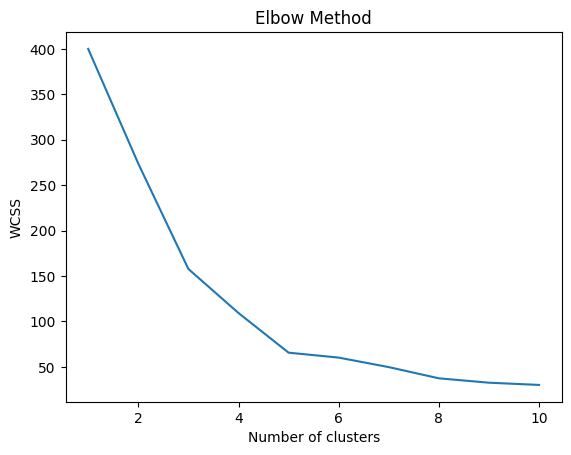

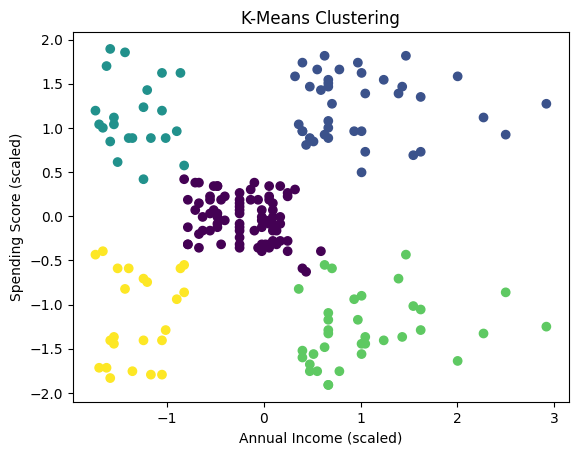

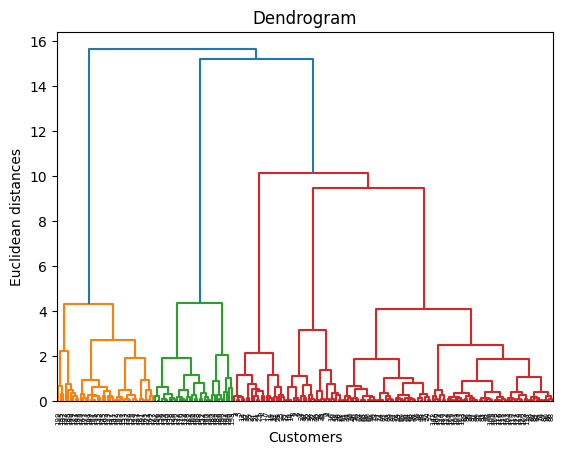

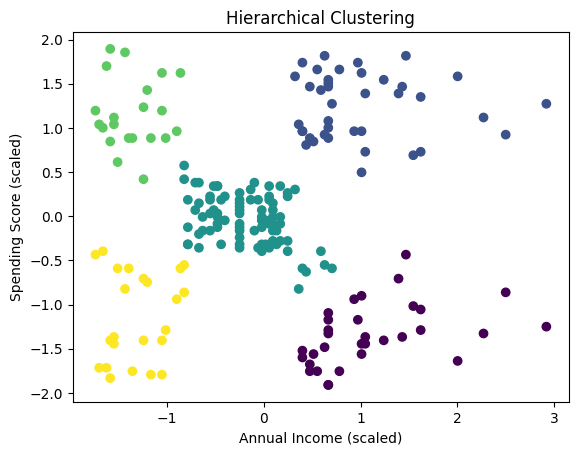

In [1]:
# ===========================
# K-Means + Hierarchical Clustering
# ===========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# ===========================
# STEP 1: LOAD DATASET
# ===========================

# Download CSV from Kaggle and place in same folder
data = pd.read_csv("Mall_Customers.csv")

print("First 5 rows:\n", data.head())

# ===========================
# STEP 2: SELECT FEATURES
# ===========================

# We take Annual Income and Spending Score
X = data.iloc[:, [3, 4]].values

# ===========================
# STEP 3: FEATURE SCALING
# ===========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===========================
# STEP 4: K-MEANS CLUSTERING
# ===========================

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# Apply K-Means with optimal clusters (choose 5 usually)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# ===========================
# STEP 5: HIERARCHICAL CLUSTERING
# ===========================

# Dendrogram
plt.figure()
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean distances")
plt.show()

# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_hc)
plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()